# Transformers & Sequence Modelling Experimental Suite

This executed notebook presents the committed evidence for **Step 011.2**.
It compares deterministic tokenization, a dense embedding baseline, TF-IDF,
TextCNN, GRU, LSTM, and a small Transformer encoder on the automotive-part
text descriptions.

Only the committed **train** and **validation** splits are used. The locked
test split is not opened or scored. The optional pretrained-transformer task
remains gated because pretrained downloads require explicit authorization.


## Sequence modelling setup

A description is tokenized to a fixed-length integer sequence
\(x=(x_1,\ldots,x_L)\). Neural models estimate

\[
p_\theta(y\mid x)=\operatorname{softmax}(f_\theta(x)),
\]

and are compared using validation accuracy and Macro F1. The Transformer uses
multi-head self-attention

\[
\operatorname{Attention}(Q,K,V)=
\operatorname{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V.
\]


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd()
REPORT_ROOT = PROJECT_ROOT / "reports" / "course_coverage" / "sequence"
print("Runtime: project virtual environment")
print("Working directory: repository root")


Runtime: project virtual environment
Working directory: repository root


## SEQ-001 and SEQ-002 — Text audit and deterministic loader


{
  "step": "011.2",
  "status": "PASS",
  "train": {
    "rows": 180,
    "groups": 60,
    "unique_descriptions": 14,
    "label_counts": {
      "MATCH": 60,
      "PARTIAL_MATCH": 60,
      "MISMATCH": 60
    },
    "token_length": {
      "minimum": 2,
      "median": 3.0,
      "mean": 3.1,
      "maximum": 4
    },
    "unique_token_count": 20
  },
  "validation": {
    "rows": 60,
    "groups": 20,
    "unique_descriptions": 14,
    "label_counts": {
      "MATCH": 20,
      "PARTIAL_MATCH": 20,
      "MISMATCH": 20
    },
    "token_length": {
      "minimum": 2,
      "median": 3.0,
      "mean": 3.1,
      "maximum": 4
    },
    "unique_token_count": 20
  },
  "group_overlap": 0,
  "label_order": [
    "MATCH",
    "PARTIAL_MATCH",
    "MISMATCH"
  ],
  "text_column": "description",
  "locked_test_csv_files_opened": false,
  "test_split_used": false,
  "final_test_evaluation_authorized": false,
  "production_final_model_changed": false,
  "pretrained_weights_downloaded": fa

,split,sample_id,part_category,description,label
0,train,air_filter_001_01_match,air_filter,Automotive air filter.,MATCH
1,train,air_filter_002_01_match,air_filter,Automotive air filter.,MATCH
2,train,air_filter_001_01_partial_match,air_filter,Automotive oil filter.,PARTIAL_MATCH
3,train,air_filter_002_01_partial_match,air_filter,Automotive oil filter.,PARTIAL_MATCH
4,train,air_filter_001_01_mismatch,air_filter,Automotive starter motor.,MISMATCH
5,train,air_filter_002_01_mismatch,air_filter,Automotive starter motor.,MISMATCH
6,validation,air_filter_004_01_match,air_filter,Automotive air filter.,MATCH
7,validation,alternator_004_01_match,alternator,Automotive alternator.,MATCH
8,validation,air_filter_004_01_partial_match,air_filter,Automotive oil filter.,PARTIAL_MATCH
9,validation,alternator_004_01_partial_match,alternator,Automotive starter motor.,PARTIAL_MATCH


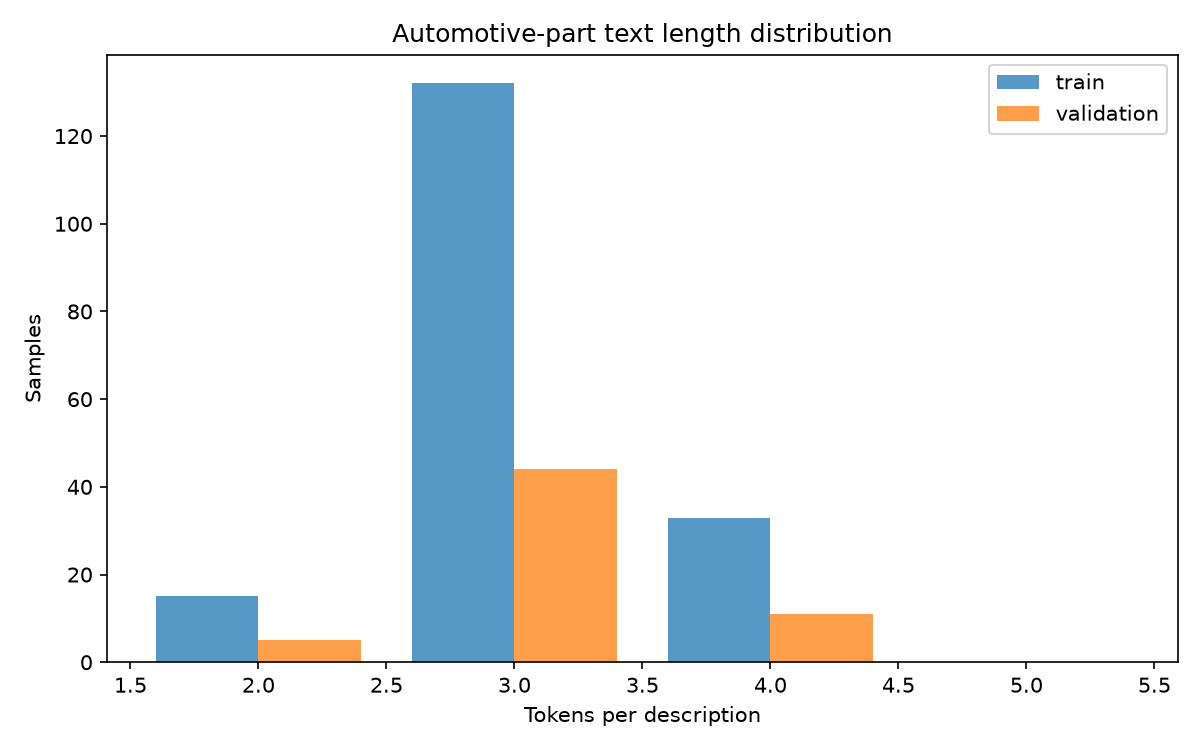

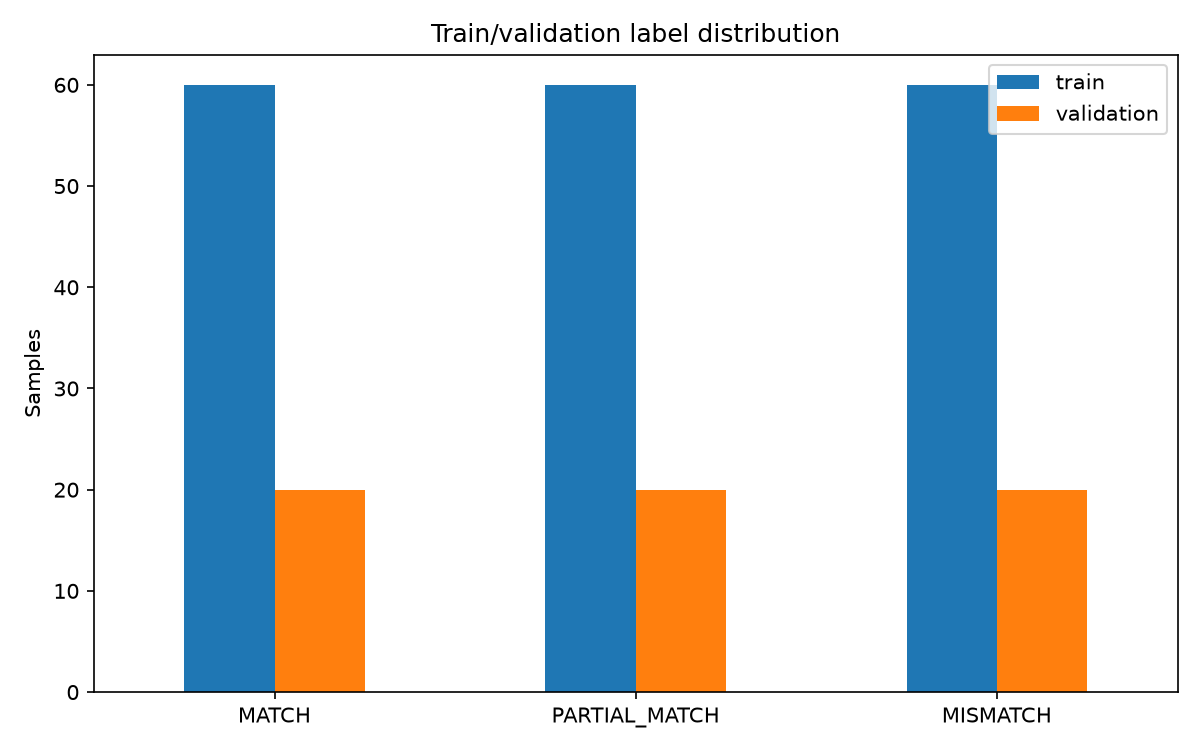

In [2]:
profile = json.loads((REPORT_ROOT / "text_profile.json").read_text())
loader = json.loads((REPORT_ROOT / "text_loader_contract.json").read_text())
examples = pd.read_csv(REPORT_ROOT / "representative_examples.csv")
print(json.dumps(profile, indent=2))
print(json.dumps(loader, indent=2))
display(examples)
display(Image(filename=str(REPORT_ROOT / "figures" / "text_length_distribution.png")))
display(Image(filename=str(REPORT_ROOT / "figures" / "label_distribution.png")))


## SEQ-003 — Tokenization and padded integer sequences


In [3]:
tokenization = json.loads((REPORT_ROOT / "tokenization_summary.json").read_text())
token_examples = pd.read_csv(REPORT_ROOT / "tokenization_examples.csv")
print(json.dumps(tokenization, indent=2))
display(token_examples.head(12))


{
  "status": "PASS",
  "token_pattern": "[a-z0-9]+",
  "lowercase": true,
  "vocabulary_fit_split": "train_only",
  "vocabulary_size": 22,
  "maximum_vocabulary_size": 1000,
  "sequence_length": 12,
  "padding": "post",
  "truncation": "post",
  "padding_index": 0,
  "unknown_index": 1,
  "train_shape": [
    180,
    12
  ],
  "validation_shape": [
    60,
    12
  ],
  "test_split_used": false
}


,sample_id,description,tokens,encoded_sequence,decoded_non_padding,label
0,air_filter_001_01_match,Automotive air filter.,"[""automotive"", ""air"", ""filter""]","[2, 14, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[""automotive"", ""air"", ""filter""]",MATCH
1,air_filter_001_01_mismatch,Automotive starter motor.,"[""automotive"", ""starter"", ""motor""]","[2, 12, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[""automotive"", ""starter"", ""motor""]",MISMATCH
2,air_filter_001_01_partial_match,Automotive oil filter.,"[""automotive"", ""oil"", ""filter""]","[2, 10, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[""automotive"", ""oil"", ""filter""]",PARTIAL_MATCH
3,air_filter_002_01_match,Automotive air filter.,"[""automotive"", ""air"", ""filter""]","[2, 14, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[""automotive"", ""air"", ""filter""]",MATCH
4,air_filter_002_01_mismatch,Automotive starter motor.,"[""automotive"", ""starter"", ""motor""]","[2, 12, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[""automotive"", ""starter"", ""motor""]",MISMATCH
5,air_filter_002_01_partial_match,Automotive oil filter.,"[""automotive"", ""oil"", ""filter""]","[2, 10, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[""automotive"", ""oil"", ""filter""]",PARTIAL_MATCH
6,air_filter_004_01_match,Automotive air filter.,"[""automotive"", ""air"", ""filter""]","[2, 14, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[""automotive"", ""air"", ""filter""]",MATCH
7,air_filter_004_01_mismatch,Automotive starter motor.,"[""automotive"", ""starter"", ""motor""]","[2, 12, 9, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[""automotive"", ""starter"", ""motor""]",MISMATCH
8,air_filter_004_01_partial_match,Automotive oil filter.,"[""automotive"", ""oil"", ""filter""]","[2, 10, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[""automotive"", ""oil"", ""filter""]",PARTIAL_MATCH
9,alternator_004_01_match,Automotive alternator.,"[""automotive"", ""alternator""]","[2, 15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[""automotive"", ""alternator""]",MATCH


## SEQ-004 to SEQ-007 — Baselines and sequence architectures


,experiment_id,run_id,family,variant,seed,status,parameter_count,epochs_completed,best_epoch,training_time_seconds,...,final_train_loss,final_validation_loss,generalization_gap,notes,selected_run_id,run_count,mean_macro_f1,std_macro_f1,per_class_f1,per_class_support
0,SEQ-005,tfidf-ngram-1-1-c-1,tfidf_logistic,ngram-1-1-c-1,42,COMPLETED,63,1,1,0.004235,...,NaN,NaN,0.000000,TF-IDF vocabulary=20; classical baseline.,tfidf-ngram-1-1-c-1,6,0.329966,0.000000,"{""MATCH"": 0.0, ""PARTIAL_MATCH"": 0.444444444444...","{""MATCH"": 20, ""PARTIAL_MATCH"": 20, ""MISMATCH"":..."
1,SEQ-006,textcnn-seed-44,textcnn,textcnn,44,COMPLETED,3755,3,3,0.980802,...,1.096101,1.095744,0.022222,Keras sequence model; train/validation only.,textcnn-seed-44,3,0.306079,0.016331,"{""MATCH"": 0.16, ""PARTIAL_MATCH"": 0.27586206896...","{""MATCH"": 20, ""PARTIAL_MATCH"": 20, ""MISMATCH"":..."
2,SEQ-004,embedding_average-seed-42,embedding_average,embedding_average,42,COMPLETED,1227,3,3,0.679597,...,1.097895,1.098391,0.027778,Keras sequence model; train/validation only.,embedding_average-seed-42,3,0.235697,0.051837,"{""MATCH"": 0.0, ""PARTIAL_MATCH"": 0.456140350877...","{""MATCH"": 20, ""PARTIAL_MATCH"": 20, ""MISMATCH"":..."
3,SEQ-007,transformer-seed-43,transformer,transformer,43,COMPLETED,5499,3,3,1.507147,...,1.321886,1.096155,-0.011111,Keras sequence model; train/validation only.,transformer-seed-43,3,0.226391,0.042819,"{""MATCH"": 0.41379310344827586, ""PARTIAL_MATCH""...","{""MATCH"": 20, ""PARTIAL_MATCH"": 20, ""MISMATCH"":..."
4,SEQ-006,gru-seed-42,gru,gru,42,COMPLETED,5175,3,2,1.007726,...,1.099188,1.098619,-0.005556,Keras sequence model; train/validation only.,gru-seed-42,3,0.175607,0.012644,"{""MATCH"": 0.4935064935064935, ""PARTIAL_MATCH"":...","{""MATCH"": 20, ""PARTIAL_MATCH"": 20, ""MISMATCH"":..."
5,SEQ-006,lstm-seed-42,lstm,lstm,42,COMPLETED,6575,3,3,0.977365,...,1.098589,1.098560,0.011111,Keras sequence model; train/validation only.,lstm-seed-42,3,0.166667,0.000000,"{""MATCH"": 0.0, ""PARTIAL_MATCH"": 0.0, ""MISMATCH...","{""MATCH"": 20, ""PARTIAL_MATCH"": 20, ""MISMATCH"":..."


Recorded training runs: 21


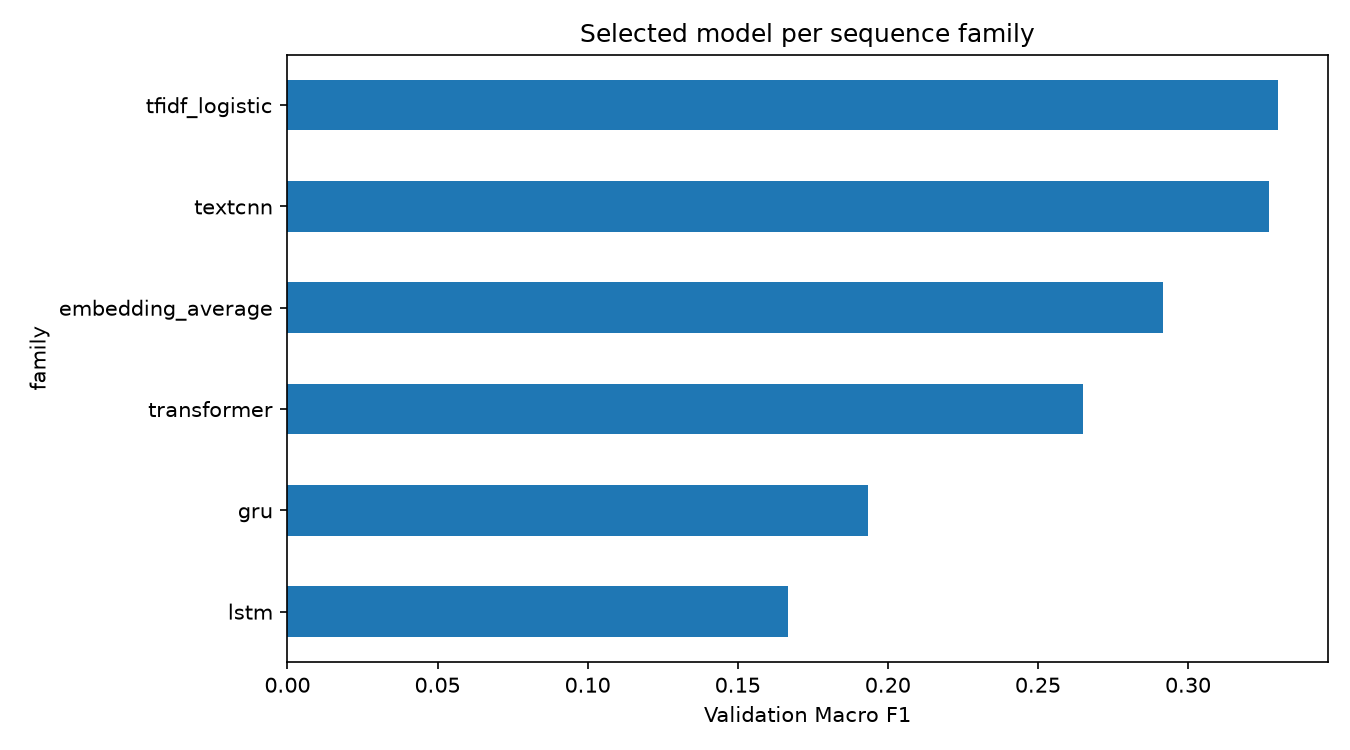

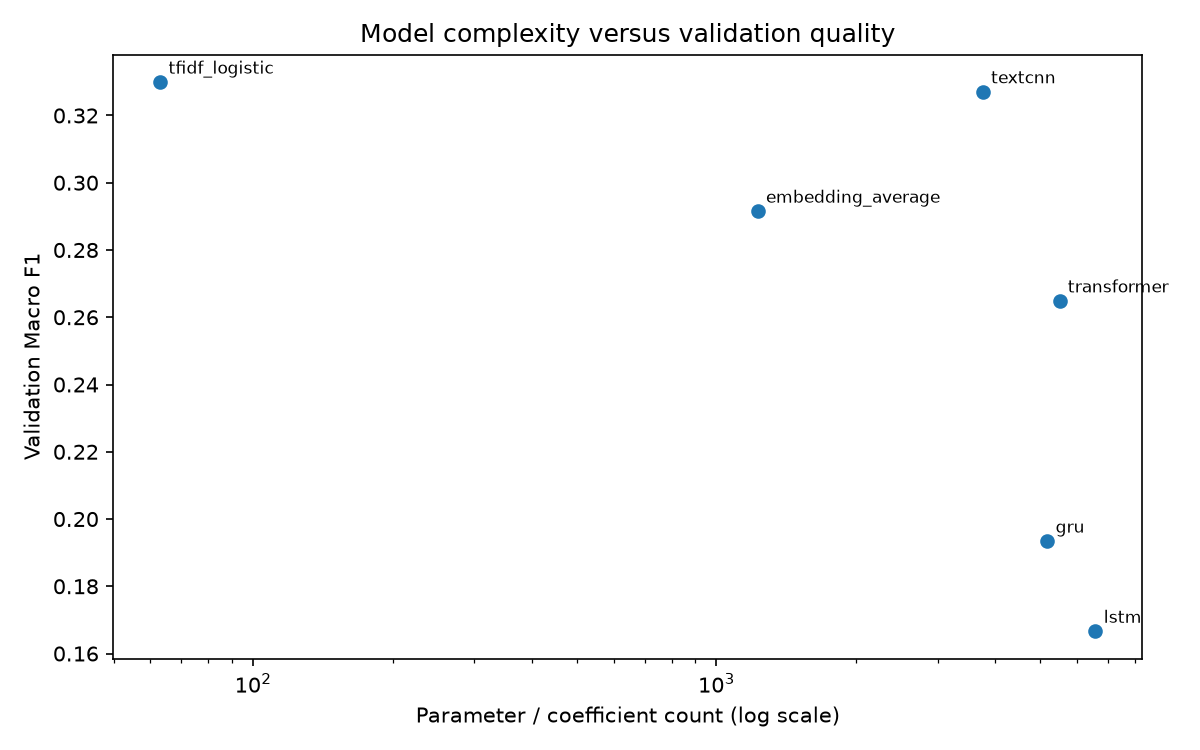

In [4]:
comparison = pd.read_csv(REPORT_ROOT / "model_comparison.csv")
runs = pd.read_csv(REPORT_ROOT / "training_runs.csv")
display(comparison.sort_values(["validation_macro_f1", "validation_accuracy"], ascending=False))
print("Recorded training runs:", len(runs))
display(Image(filename=str(REPORT_ROOT / "figures" / "model_macro_f1.png")))
display(Image(filename=str(REPORT_ROOT / "figures" / "complexity_tradeoff.png")))


## SEQ-008 — Validation comparison, ROC evidence, and errors


Validation errors recorded: 35


,sample_id,description,part_category,true_label,predicted_label,predicted_probability,true_label_probability,probability_margin,error_type,selected_model_family,selected_run_id
0,air_filter_004_01_match,Automotive air filter.,air_filter,MATCH,PARTIAL_MATCH,0.396398,0.396398,5.609069e-12,MATCH→PARTIAL_MATCH,tfidf_logistic,tfidf-ngram-1-1-c-1
1,air_filter_004_01_partial_match,Automotive oil filter.,air_filter,PARTIAL_MATCH,MISMATCH,0.409840,0.295080,1.147594e-01,PARTIAL_MATCH→MISMATCH,tfidf_logistic,tfidf-ngram-1-1-c-1
2,alternator_004_01_match,Automotive alternator.,alternator,MATCH,PARTIAL_MATCH,0.389833,0.389833,5.440981e-12,MATCH→PARTIAL_MATCH,tfidf_logistic,tfidf-ngram-1-1-c-1
3,alternator_004_01_partial_match,Automotive starter motor.,alternator,PARTIAL_MATCH,MISMATCH,0.412306,0.293847,1.184585e-01,PARTIAL_MATCH→MISMATCH,tfidf_logistic,tfidf-ngram-1-1-c-1
4,brake_disc_004_01_match,Automotive brake disc.,brake_disc,MATCH,MISMATCH,0.408419,0.295791,1.126281e-01,MATCH→MISMATCH,tfidf_logistic,tfidf-ngram-1-1-c-1
5,brake_pad_004_01_match,Automotive brake pad set.,brake_pad,MATCH,PARTIAL_MATCH,0.418167,0.418167,5.783762e-12,MATCH→PARTIAL_MATCH,tfidf_logistic,tfidf-ngram-1-1-c-1
6,brake_pad_004_01_partial_match,Automotive brake disc.,brake_pad,PARTIAL_MATCH,MISMATCH,0.408419,0.295791,1.126281e-01,PARTIAL_MATCH→MISMATCH,tfidf_logistic,tfidf-ngram-1-1-c-1
7,coil_spring_004_01_match,Automotive coil spring.,coil_spring,MATCH,PARTIAL_MATCH,0.414311,0.414311,5.641654e-12,MATCH→PARTIAL_MATCH,tfidf_logistic,tfidf-ngram-1-1-c-1
8,coil_spring_004_01_partial_match,Automotive shock absorber.,coil_spring,PARTIAL_MATCH,MISMATCH,0.412306,0.293847,1.184585e-01,PARTIAL_MATCH→MISMATCH,tfidf_logistic,tfidf-ngram-1-1-c-1
9,external_sample_air_filter_475881_match,Automotive engine air filter.,air_filter,MATCH,PARTIAL_MATCH,0.380420,0.380420,5.402456e-12,MATCH→PARTIAL_MATCH,tfidf_logistic,tfidf-ngram-1-1-c-1


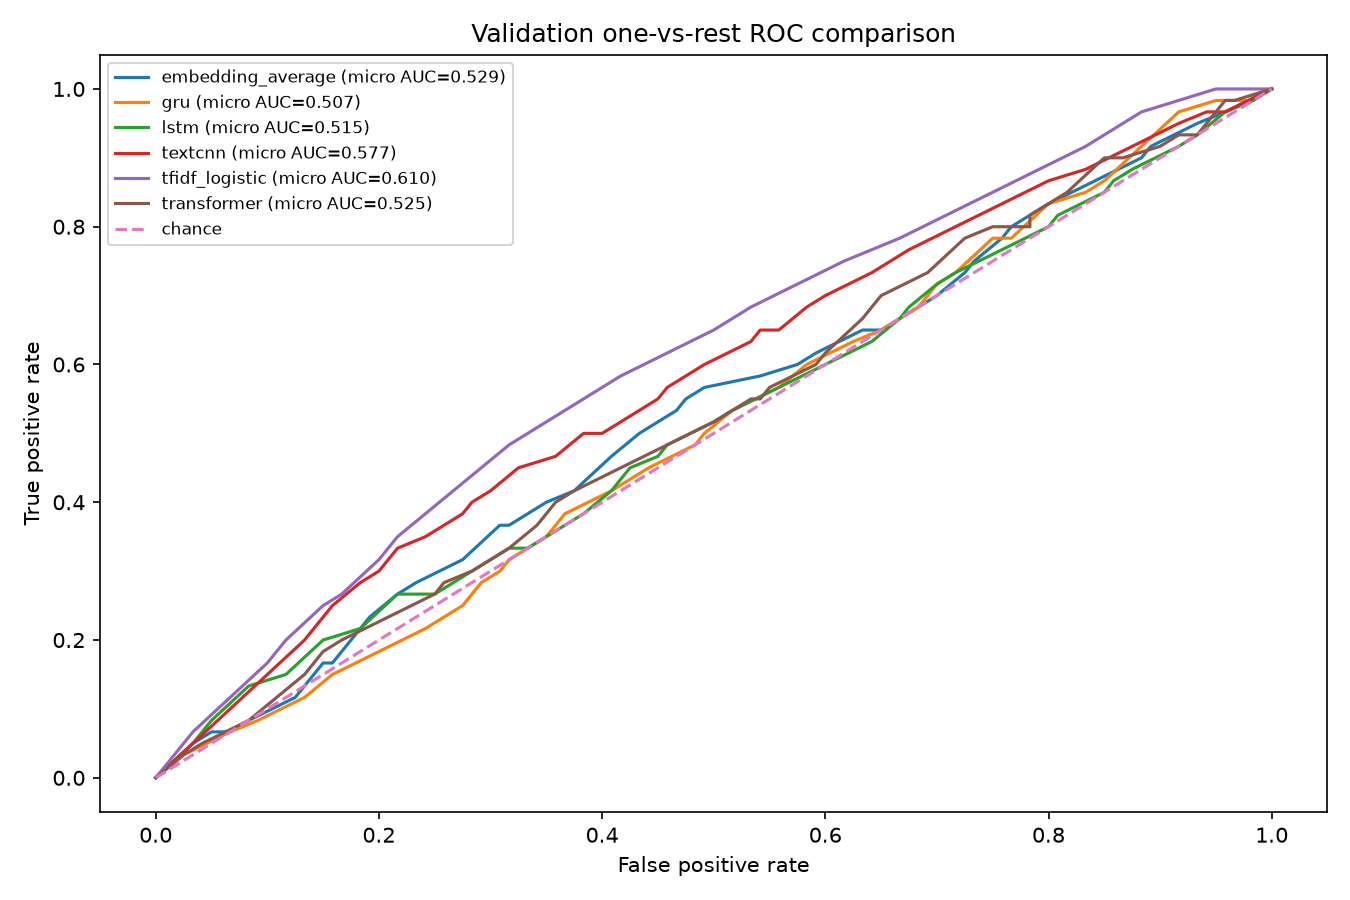

In [5]:
errors = pd.read_csv(REPORT_ROOT / "validation_error_analysis.csv")
print("Validation errors recorded:", len(errors))
display(errors.head(15))
display(Image(filename=str(REPORT_ROOT / "figures" / "roc_curves.png")))


## SEQ-009 — Multi-head attention inspection


{
  "correct": {
    "sample_id": "alternator_004_01_match",
    "description": "Automotive alternator.",
    "tokens": [
      "automotive",
      "alternator"
    ],
    "true_label": "MATCH",
    "predicted_label": "MATCH",
    "correct": true,
    "heads": [
      {
        "head": 1,
        "matrix": [
          [
            0.08339851349592209,
            0.08329005539417267
          ],
          [
            0.08319933712482452,
            0.08326342701911926
          ]
        ],
        "top_attended_tokens": [
          "automotive",
          "alternator"
        ]
      },
      {
        "head": 2,
        "matrix": [
          [
            0.08368934690952301,
            0.08360383659601212
          ],
          [
            0.08365023136138916,
            0.08359109610319138
          ]
        ],
        "top_attended_tokens": [
          "automotive",
          "alternator"
        ]
      }
    ]
  },
  "incorrect": {
    "sample_id": "air_filter_004_01_ma

,selection,sample_id,head,token_position,token,mean_attention_received
0,correct,alternator_004_01_match,1,0,automotive,0.083299
1,correct,alternator_004_01_match,1,1,alternator,0.083277
2,correct,alternator_004_01_match,2,0,automotive,0.083670
3,correct,alternator_004_01_match,2,1,alternator,0.083597
4,incorrect,air_filter_004_01_match,1,0,automotive,0.083274
5,incorrect,air_filter_004_01_match,1,1,air,0.083267
6,incorrect,air_filter_004_01_match,1,2,filter,0.083235
7,incorrect,air_filter_004_01_match,2,0,automotive,0.083577
8,incorrect,air_filter_004_01_match,2,1,air,0.083418
9,incorrect,air_filter_004_01_match,2,2,filter,0.083461


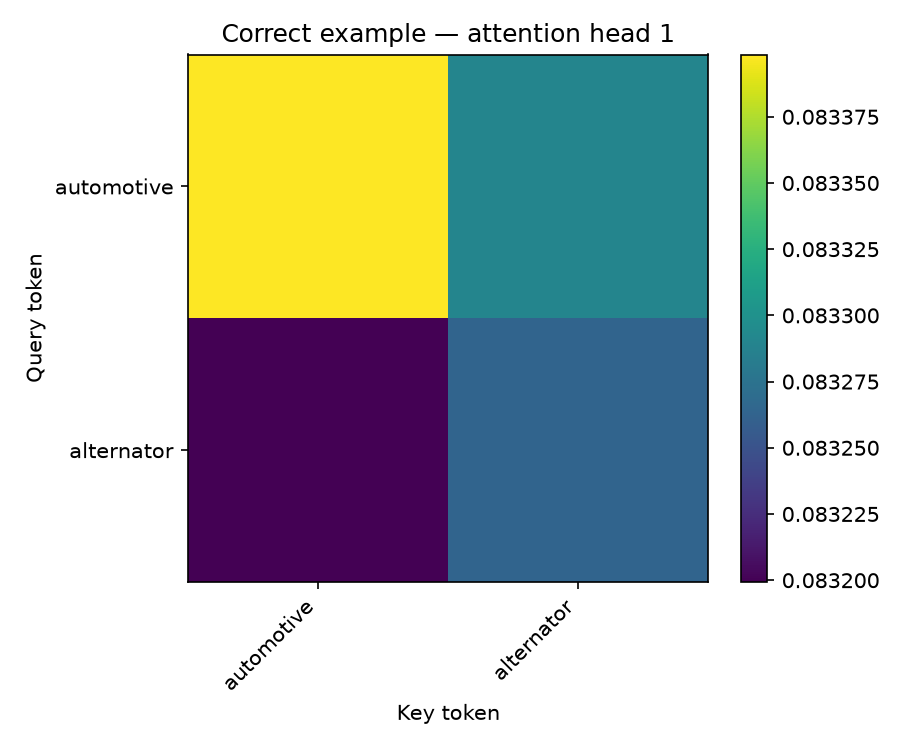

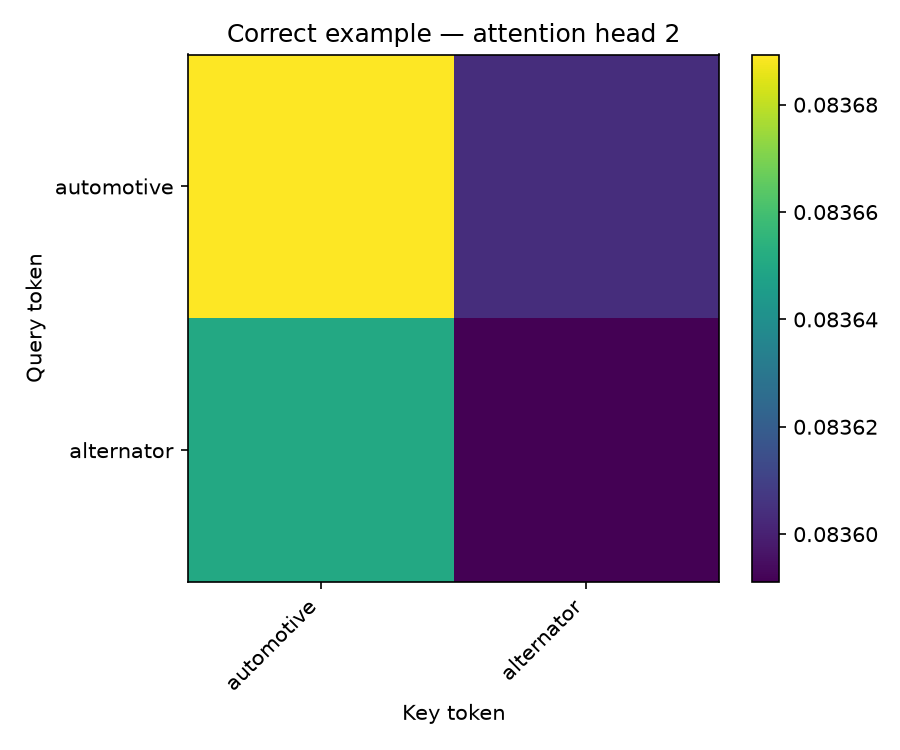

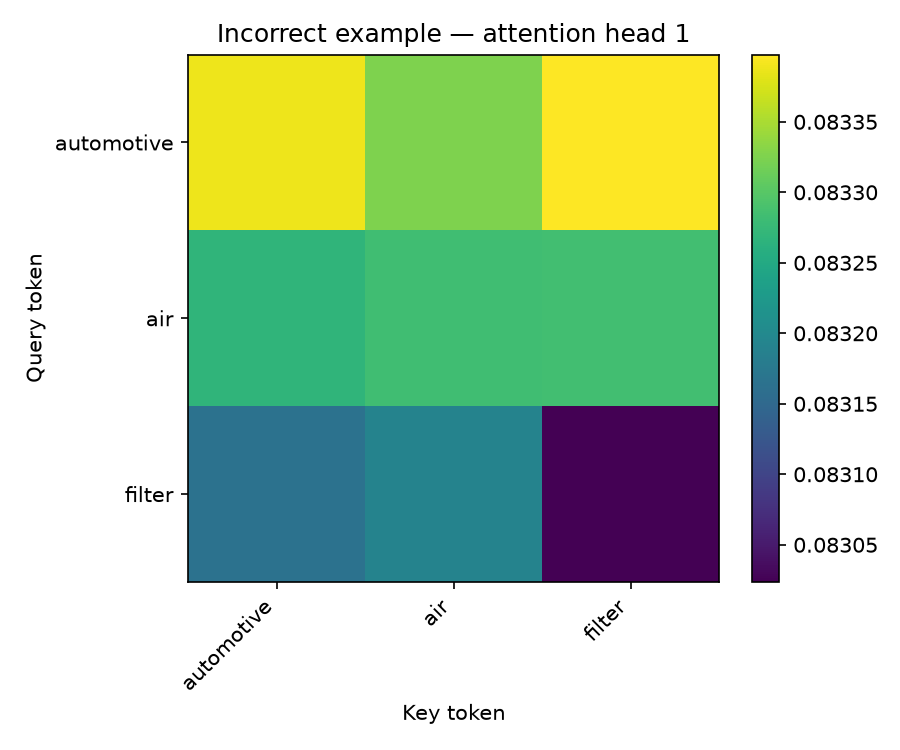

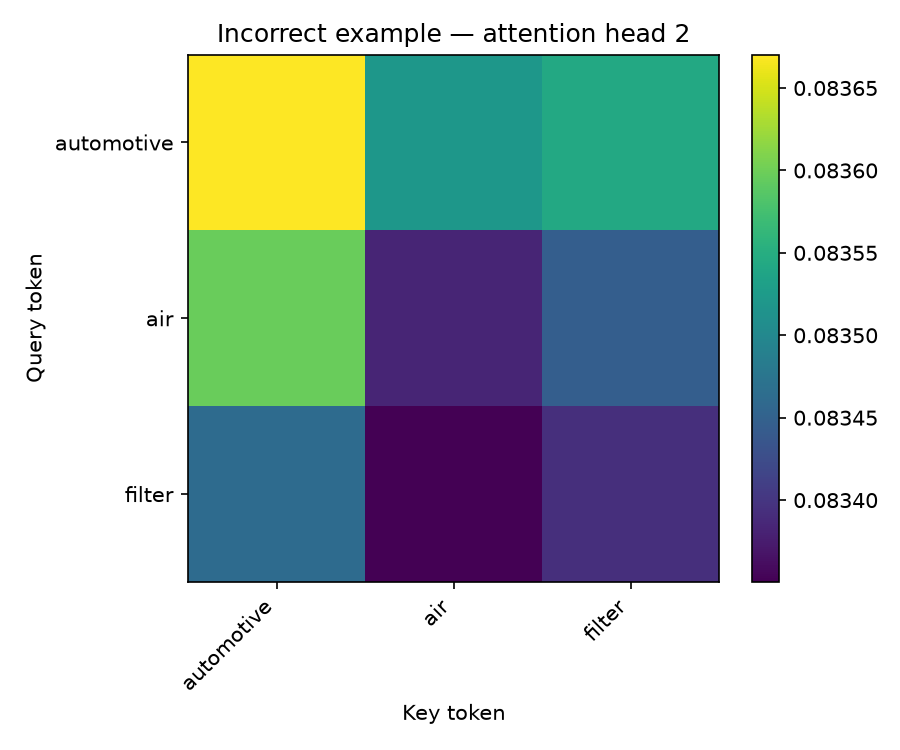

In [6]:
attention = json.loads((REPORT_ROOT / "attention_evidence.json").read_text())
attention_summary = pd.read_csv(REPORT_ROOT / "attention_token_summary.csv")
print(json.dumps(attention["selection"], indent=2))
display(attention_summary)
for name in [
    "attention_correct_head_1.png", "attention_correct_head_2.png",
    "attention_incorrect_head_1.png", "attention_incorrect_head_2.png",
]:
    display(Image(filename=str(REPORT_ROOT / "figures" / name)))


## SEQ-010 — Explicit pretrained-transformer gate


In [7]:
gate = json.loads((REPORT_ROOT / "pretrained_transformer_gate.json").read_text())
print(json.dumps(gate, indent=2))
assert gate["status"] == "DEFERRED_EXPLICIT_APPROVAL_REQUIRED"
assert gate["pretrained_weights_downloaded"] is False


{
  "experiment_id": "SEQ-010",
  "status": "DEFERRED_EXPLICIT_APPROVAL_REQUIRED",
  "reason": "Downloading pretrained transformer weights requires explicit user authorization and license/revision recording.",
  "approval_received": false,
  "network_download_attempted": false,
  "pretrained_weights_downloaded": false,
  "pretrained_model_loaded": false,
  "model_identifier": null,
  "model_revision": null,
  "model_license": null,
  "test_split_used": false,
  "final_test_evaluation_authorized": false
}


## Final locked state


In [8]:
status = json.loads((REPORT_ROOT / "sequence_suite_status.json").read_text())
print(json.dumps(status, indent=2))
assert status["status"] == "PASS"
assert status["test_split_used"] is False
assert status["final_test_evaluation_authorized"] is False
assert status["production_final_model_changed"] is False
assert status["pretrained_weights_downloaded"] is False


{
  "step": "011.2",
  "status": "PASS",
  "readiness": "SEQUENCE_EXPERIMENTAL_SUITE_CORE_COMPLETE_PRETRAINED_GATE_TEST_LOCKED",
  "base_checkpoint": "cfb6bba",
  "sequence_exercise_problems": "9/9 core completed; 1/1 pretrained extension gated",
  "completed_problem_ids": [
    "SEQ-001",
    "SEQ-002",
    "SEQ-003",
    "SEQ-004",
    "SEQ-005",
    "SEQ-006",
    "SEQ-007",
    "SEQ-008",
    "SEQ-009"
  ],
  "deferred_problem_ids": [
    "SEQ-010"
  ],
  "required_core_problem_count": 9,
  "completed_core_problem_count": 9,
  "training_runs_recorded": 21,
  "model_families_compared": [
    "embedding_average",
    "gru",
    "lstm",
    "textcnn",
    "tfidf_logistic",
    "transformer"
  ],
  "selected_educational_validation_run": "tfidf-ngram-1-1-c-1",
  "selected_educational_validation_family": "tfidf_logistic",
  "selected_validation_accuracy": 0.4166666666666667,
  "selected_validation_macro_f1": 0.32996632996632996,
  "selection_scope": "educational_validation_only",
  "prod

## Conclusion

The core sequence-modelling suite is complete and reproducible: deterministic
loading and tokenization, six model families, validation-only comparison,
error analysis, and attention-head evidence. It is an educational experimental
extension and does not alter the frozen production/final model. The pretrained
extension remains intentionally gated rather than silently downloading weights.
